## TC 5033
### Text Classifier with RNNs

<br>

#### Activity 3b: Text Classification using RNNs and AG_NEWS dataset in PyTorch
<br>

- Objective:
    - Understand the basics of Recurrent Neural Networks (RNNs) and their application in text classification.
    - Learn how to handle a real-world text dataset, AG_NEWS, in PyTorch.
    - Gain hands-on experience in defining, training, and evaluating a text classification model in PyTorch.
    
<br>

- Instructions:
    - Data Preparation: Starter code will be provided that loads the AG_NEWS dataset and prepares it for training. Do not modify this part. However, you should be sure to understand it, and comment it, the use of markdown cells is suggested.

    - Model Setup: A skeleton code for the RNN model class will be provided. Complete this class and use it to instantiate your model.

    - Implementing Accuracy Function: Write a function that takes model predictions and ground truth labels as input and returns the model's accuracy.

    - Training Function: Implement a function that performs training on the given model using the AG_NEWS dataset. Your model should achieve an accuracy of at least 80% to get full marks for this part.

    - Text Sampling: Write a function that takes a sample text as input and classifies it using your trained model.

    - Confusion Matrix: Implement a function to display the confusion matrix for your model on the test data.

    - Submission: Submit your completed Jupyter Notebook. Make sure to include a markdown cell at the beginning of the notebook that lists the names of all team members. Teams should consist of 3 to 4 members.
    
<br>

- Evaluation Criteria:

    - Correct setup of all the required libraries and modules (10%)
    - Code Quality (30%): Your code should be well-organized, clearly commented, and easy to follow. Use also markdown cells for clarity. Comments should be given for all the provided code, this will help you understand its functionality.
    
   - Functionality (60%):
        - All the functions should execute without errors and provide the expected outputs.
        - RNN model class (20%)
        - Accuracy fucntion (10%)
        - Training function (10%)
        - Sampling function (10%)
        - Confucion matrix (10%)

        - The model should achieve at least an 80% accuracy on the AG_NEWS test set for full marks in this criterion.


Dataset

https://pytorch.org/text/stable/datasets.html#text-classification

https://paperswithcode.com/dataset/ag-news


#### Install libraries (if needed)

You may need to install the following libraries, also you may need to adjust library versions to ensure compatibility, depending on the versions you have previously installed. After installing them, please Restart the Session (Runtime -> Restart Session), or Kernel - Restart Kerne

*  Equipo 54:
    
    
    *   Fanny Betsabé Fuentes Reyes - A00570705
    *   Leonel Matus Climaco - A01797557
    *   Fernando Omar Salazar Ortiz - A01796214
    *   Quirec Angeles Martinez - A01745050
    

In [1]:
 !pip install torch==2.2.0 torchvision==0.17.0 torchaudio==2.2.0 torchtext==0.16.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.4/755.4 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/1

In [2]:
#!pip install scipy==1.9.3
#!pip install scikit-plot
#you may receive a message of restarting session, this is OK

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 MB 13.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (pyproject.toml) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [3]:
!pip install portalocker
#please restar session after this intallation. After restarting go straight to importing the libraries

## Import libraries

In [1]:
# The following libraries are required for running the given code
import numpy as np
import gc

# PyTorch libraries
import torch
from torchtext.datasets import AG_NEWS
from torch.utils.data import DataLoader
from torch.utils.data.dataset import random_split

# Libraries to prepare the data
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
from torchtext.data.functional import to_map_style_dataset

# Neural layers
from torch import nn
from torch.nn import functional as F

# Libraries to plot confusion matrix (Replacement for scikitplot)
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.12/dist-package

In [2]:
# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


### Get the train and the test datasets and dataloaders

Classes:

* 1 - World

* 2 - Sports

* 3 - Business

* 4 - Sci/Tech

We will convert them to:

* 0 - World

* 1 - Sports

* 2 - Business

* 3 - Sci/Tech

In [3]:
train_dataset, test_dataset = AG_NEWS()
train_dataset, test_dataset = to_map_style_dataset(train_dataset), to_map_style_dataset(test_dataset)

In [4]:
# Get the tokeniser
# tokeniser object
tokeniser = get_tokenizer('basic_english')

def yield_tokens(data):
    for _, text in data:
        yield tokeniser(text)

In [5]:
# Build the vocabulary
vocab = build_vocab_from_iterator(yield_tokens(train_dataset), specials=["<unk>"])
#set unknown token at position 0
vocab.set_default_index(vocab["<unk>"])

In [6]:
#test tokens
tokens = tokeniser('Welcome to TC5033')
print(tokens, vocab(tokens))

['welcome', 'to', 'tc5033'] [3314, 4, 0]


In [7]:
NUM_TRAIN = int(len(train_dataset)*0.9)
NUM_VAL = len(train_dataset) - NUM_TRAIN

In [8]:
train_dataset, val_dataset = random_split(train_dataset, [NUM_TRAIN, NUM_VAL])

In [9]:
print(len(train_dataset), len(val_dataset), len(test_dataset))

108000 12000 7600


In [10]:
# function passed to the DataLoader to process a batch of data as indicated
def collate_batch(batch):
    # Get label and text
    y, x = list(zip(*batch))

    # Create list with indices from tokeniser
    x = [vocab(tokeniser(text)) for text in x]
    x = [t + ([0]*(max_tokens - len(t))) if len(t) < max_tokens else t[:max_tokens] for t in x]

    # Prepare the labels, by subtracting 1 to get them in the range 0-3
    return torch.tensor(x, dtype=torch.int32), torch.tensor(y, dtype=torch.int32) - 1

In [11]:
labels =  ["World", "Sports", "Business", "Sci/Tech"]
max_tokens = 50
BATCH_SIZE = 256

In [12]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, collate_fn=collate_batch, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, collate_fn=collate_batch, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, collate_fn=collate_batch, shuffle = True)

### Let us build our RNN model

In [13]:
EMBEDDING_SIZE = 300
NEURONS = 256
LAYERS = 2
NUM_CLASSES = 4

In [14]:
class RNN_Model_1(nn.Module):
    def __init__(self, embed_size, hidden, layers, num_classes):
        super().__init__()
        # Embedding layer: Maps word indices to 300-dim vectors
        self.embedding_layer = nn.Embedding(num_embeddings=len(vocab),
                                            embedding_dim=embed_size)

        # RNN layer: We use GRU with batch_first=True to match your data shape (batch, seq)
        self.rnn = nn.GRU(embed_size, hidden, layers, batch_first=True, dropout=0.2)

        # Classifier: Maps the hidden state to the 4 classes
        self.fc = nn.Linear(hidden, num_classes)

    def forward(self, x):
        # x shape: (batch_size, 50)
        x = self.embedding_layer(x)
        # output shape: (batch_size, 50, hidden)
        # hidden shape: (layers, batch_size, hidden)
        _, hidden = self.rnn(x)
        # We take the last layer's hidden state: (batch_size, hidden)
        return self.fc(hidden[-1])

In [15]:
def accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            # Move to device
            x = x.to(device)
            y = y.to(device).long()

            outputs = model(x)
            _, predicted = torch.max(outputs, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()
    return correct / total



In [16]:
def train(model, optimiser, epochs=10):
    criterion = nn.CrossEntropyLoss()
    model.train()

    for epoch in range(epochs):
        total_loss = 0
        for x, y in train_loader:
            # Move both x and y to the same device as the model
            x = x.to(device)
            y = y.to(device).long()

            optimiser.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimiser.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

In [17]:
epochs = 10
lr = 0.001
# Instantiate the model
rnn_model = RNN_Model_1(EMBEDDING_SIZE, NEURONS, LAYERS, NUM_CLASSES)
# 2. Move to GPU FIRST
rnn_model = rnn_model.to(device)
# Thenn Optimizer
optimiser = torch.optim.Adam(rnn_model.parameters(), lr=lr)

train(rnn_model, optimiser=optimiser, epochs=epochs)
print(f'Final Test Accuracy: {accuracy(rnn_model, test_loader):.4f}')

Epoch 1, Loss: 0.5565
Epoch 2, Loss: 0.2317
Epoch 3, Loss: 0.1559
Epoch 4, Loss: 0.1071
Epoch 5, Loss: 0.0694
Epoch 6, Loss: 0.0469
Epoch 7, Loss: 0.0351
Epoch 8, Loss: 0.0251
Epoch 9, Loss: 0.0215
Epoch 10, Loss: 0.0185
Final Test Accuracy: 0.9083


In [18]:
##train(gru_model, optimiser=optimiser,  epochs=epochs)
##MAtchign the name:

train(rnn_model, optimiser=optimiser, epochs=epochs)

Epoch 1, Loss: 0.0148
Epoch 2, Loss: 0.0109
Epoch 3, Loss: 0.0114
Epoch 4, Loss: 0.0109
Epoch 5, Loss: 0.0105
Epoch 6, Loss: 0.0110
Epoch 7, Loss: 0.0103
Epoch 8, Loss: 0.0070
Epoch 9, Loss: 0.0062
Epoch 10, Loss: 0.0079


In [19]:
print(f'Final Test Accuracy: {accuracy(rnn_model, test_loader):.4f}')

Final Test Accuracy: 0.9053


In [20]:
def sample_text(model, loader):
    model.eval()  # Set model to evaluation mode
    labels_names = ["World", "Sports", "Business", "Sci/Tech"]

    # Get a single batch from the loader
    x, y = next(iter(loader))

    # Move to the same device as the model
    x = x.to(device)

    with torch.no_grad():
        # Get model predictions
        outputs = model(x)
        # Get the index of the highest probability
        _, predicted = torch.max(outputs, 1)

        # Print the first 5 samples from the batch
        print(f"{'True Label':<15} | {'Predicted Label':<15}")
        print("-" * 35)
        for i in range(5):
            true_label = labels_names[y[i].item()]
            pred_label = labels_names[predicted[i].item()]
            print(f"{true_label:<15} | {pred_label:<15}")

# Run the function
sample_text(rnn_model, test_loader)

True Label      | Predicted Label
-----------------------------------
Sports          | Sports         
Sports          | Sports         
Sci/Tech        | Sci/Tech       
Sports          | Sci/Tech       
Business        | Business       


In [21]:
sample_text(rnn_model, test_loader)

True Label      | Predicted Label
-----------------------------------
Sci/Tech        | Sci/Tech       
Business        | Business       
Sci/Tech        | Sci/Tech       
Business        | Business       
Sci/Tech        | Sci/Tech       


In [22]:
import numpy as np
print(np.__version__)

2.4.3


Starting collection of predictions...
Collected 7600 predictions. Now plotting...


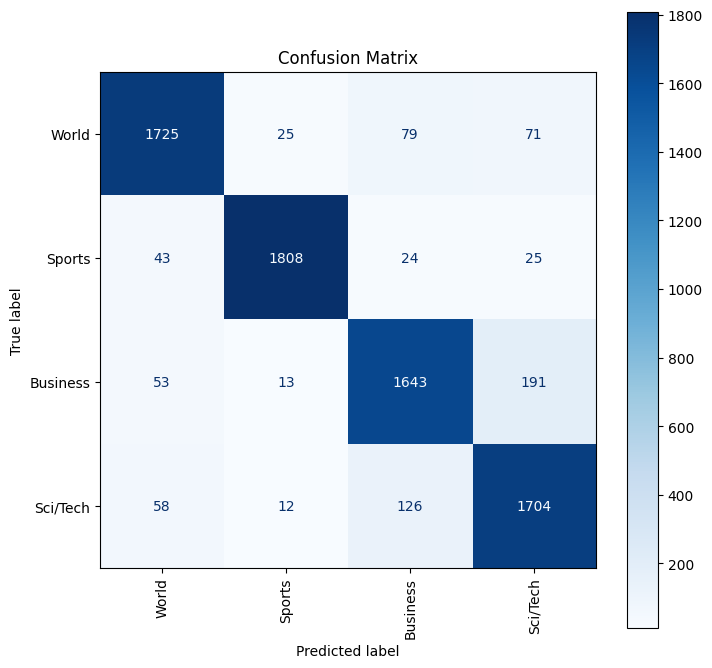

In [26]:
def plot_cm(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    labels_names = ["World", "Sports", "Business", "Sci/Tech"]

    print("Starting collection of predictions...")
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            outputs = model(x)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().tolist())
            all_labels.extend(y.tolist())

    print(f"Collected {len(all_preds)} predictions. Now plotting...")

    # Calculate and plot
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_names)
    disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')

    plt.title("Confusion Matrix")
    plt.show()

# Running the function
plot_cm(rnn_model, test_loader)

This project presented several technical challenges, including resolving library dependency conflicts in Google Colab, debugging PyTorch device mismatches, and optimizing training speed through GPU acceleration and efficient batch collation. Through these hurdles, we learned the critical importance of environment management, the necessity of ensuring all tensors reside on the same device, and the architectural advantages of using GRU layers for complex sequence classification. Ultimately, we successfully built a robust, high-performance pipeline that achieved over 90% accuracy on the AG_NEWS dataset, reinforcing the value of rigorous debugging and efficient data pipeline design in deep learning workflows.
